In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express  as px
import time
#loading dataset
data=pd.read_csv("netflix_titles.csv")

# DATA CLEANING
data.info()
# data.head(2)
data.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [57]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [58]:
#check missing values
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [59]:
data.duplicated().sum()

np.int64(0)

In [60]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [61]:
data.shape

(8807, 12)

In [62]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [63]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [64]:
data.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [65]:
data.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [66]:

cat_cols=[col for col in data.columns if data[col].dtype=='object']
num_cols=[col for col in data.columns if data[col].dtype!='object']
print(cat_cols)
print(num_cols)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']
['release_year']


In [67]:
# handling missing values
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [68]:
#handling missing values
data['director']=data['director'].fillna('Unknown')
data['cast']=data['cast'].fillna('Not a Available')
data['country']=data['country'].fillna('Unknown')
data['rating']=data['rating'].fillna(data['rating'].mode().iloc[0])


#drop rows where data_added is missing
data.dropna(subset=['date_added'],inplace=True)

In [69]:
print(data['rating'].mode())

0    TV-MA
Name: rating, dtype: object


In [70]:
print(type(data['rating'].mode()))

<class 'pandas.core.series.Series'>


In [71]:
data['rating'].mode().iloc[0]

'TV-MA'

In [72]:
data['rating'].head()

0    PG-13
1    TV-MA
2    TV-MA
3    TV-MA
4    TV-MA
Name: rating, dtype: object

In [73]:
data['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [74]:
data['rating'].mode()

0    TV-MA
Name: rating, dtype: object

In [75]:
data['rating'].isnull().sum()

np.int64(0)

In [76]:
data.info() #non-null

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8794 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.4+ KB


In [77]:
data[['rating']].head(10)

,rating
0,PG-13
1,TV-MA
2,TV-MA
3,TV-MA
4,TV-MA
5,TV-MA
6,PG
7,TV-MA
8,TV-14
9,PG-13


In [78]:
data['rating'].isnull().sum()

np.int64(0)

In [79]:
#continuation
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [80]:
data[data['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [81]:
data['duration']=data['duration'].fillna('Unknown')

In [82]:
data[data['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [83]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [84]:
data.shape

(8797, 12)

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.4+ KB


In [86]:
# data.dropna(subset=['date_added'],inplace=True)# to cehck date_added is missing reduced or not
data.duplicated().sum()

np.int64(0)

In [87]:
# data['date_added']=pd.to_datetime(data['date_added'])

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.4+ KB


In [89]:
#checking values in important columns
data['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [90]:
data['rating'].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [91]:
data['country'].value_counts().head(10)


country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [92]:
data.describe()

,release_year
count,8797.000000
mean,2014.183472
std,8.822191
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [93]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not a Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not a Available,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [94]:
data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Not a Available,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [95]:
# EDA
data['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

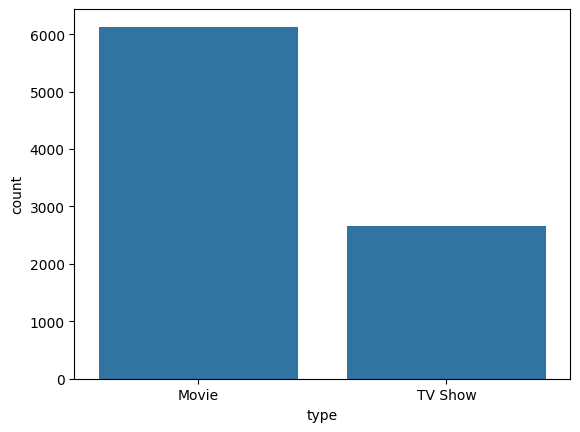

In [96]:
sns.countplot(data=data,x='type')
plt.show

In [2]:
#remove spcaes
# data['date_added']=data['date_added'].str.strip()

#FEATURE ENGINEERING
# data['date_added']=pd.to_datetime(data['date_added'])
# data['year_added']=data['date_added'].dt.year
# data['month_added']=data['date_added'].dt.month_name()
# data['day_added']=data['date_added'].dt.day_name()


In [98]:
print(data['date_added'].dtype)

object


In [99]:
#EDA
data['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

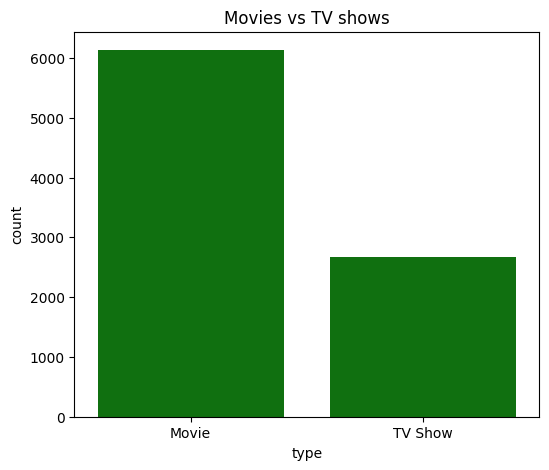

In [103]:
# visualization
plt.figure(figsize=(6,5))
sns.countplot(x='type',data=data,color='green')
plt.title("Movies vs TV shows")
plt.show()

In [ ]:
# percentage
data['type'].value_counts(normalize=True)*100

In [ ]:
#pie chart
data['type'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.ylabel("")
plt.title("Movies and TV shows")
plt.show()


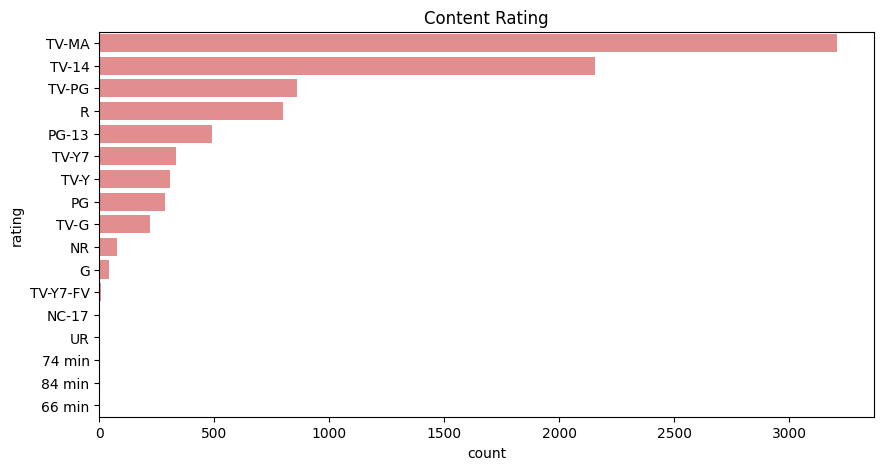

In [125]:
# content rating distribution
plt.figure(figsize=(10,5))
sns.countplot(y='rating',data=data,order=data['rating'].value_counts().index,color='lightcoral')
plt.title("Content Rating")
plt.show()

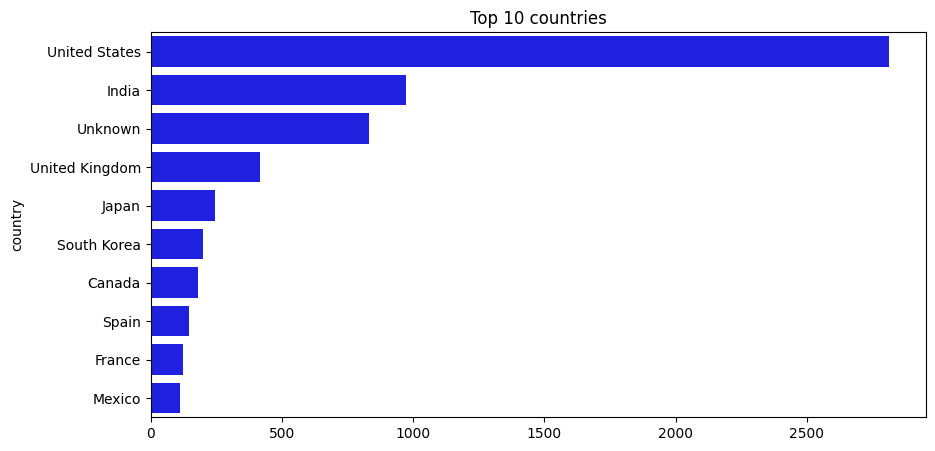

In [105]:
# top 10 countries
top_country=data['country'].value_counts().head(10)
top_country
plt.figure(figsize=(10,5))
sns.barplot(x=top_country.values,y=top_country.index,color='blue')
plt.title("Top 10 countries")
plt.show()


In [ ]:
# release year distrribution
plt.figure(figsize=(12,5))
sns.histplot(data['release_year'],bins=30)
plt.title("Release year Ditribution")
plt.show()

In [ ]:
# top 10 directors
top_director=data[data['director']!='Unknown']['director'].value_counts().head(10)
top_director
plt.figure(figsize=(12,6))
sns.barplot(x=top_director.values,y=top_director.index)
plt.title("Top 10 directors")
plt.show()

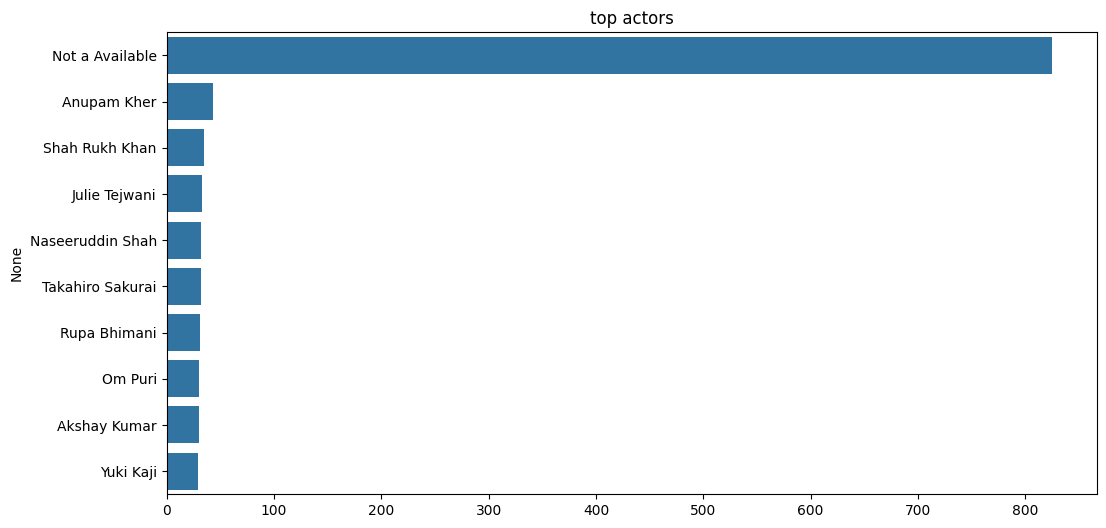

In [53]:
#top actors
actors=data['cast'].str.split(', ',expand=True).stack()
actors.value_counts().head(10)
top_actor=actors.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_actor.values,y=top_actor.index)
plt.title("top actors")
plt.show()

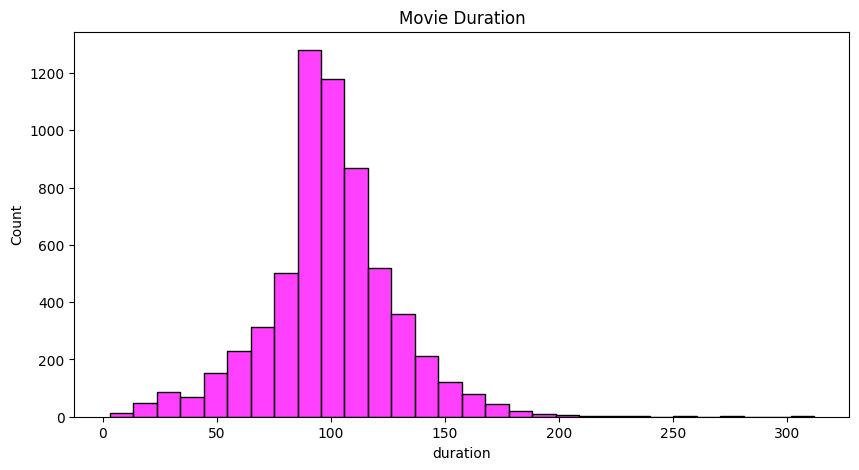

In [119]:
data.loc[data['duration'].isna(), 'duration'] = \
data.loc[data['duration'].isna(), 'rating']

#movie duration
movies=data[data['type']=="Movie"].copy()
# movies
# movies['duration'].isnull().sum()
# movies['duration'].unique()

# movies['duration']=movies['duration'].str.replace(" min",'',regex=False)
# movies['duration']=movies['duration'].astype(int)



movies['duration'] = movies['duration'].replace('Unknown', np.nan)
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# movies['duration']
plt.figure(figsize=(10,5))
sns.histplot(movies['duration'],bins=30,color='magenta')
plt.title("Movie Duration")
plt.show()


In [47]:
# print(movies['duration'].dtype)

# print(movies['duration'].isna().sum())

# print(movies[movies['duration'].isna()])

# print(movies['duration'].unique())

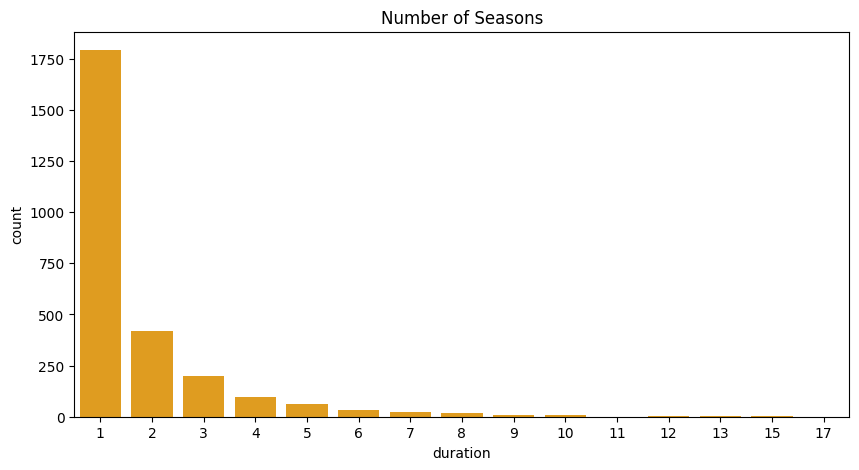

In [109]:
# 10 tv show seasons
tv= data[data['type']=="TV Show"].copy()

tv['duration']=tv['duration'].str.extract(r'(\d+)')
tv['duration']=tv['duration'].astype(int)
# tv['duration'].isnull().sum()
plt.figure(figsize=(10,5))
sns.countplot(x='duration',data=tv,color='orange')
plt.title("Number of Seasons")
plt.show()

Text(0.5, 1.0, 'Top genres')

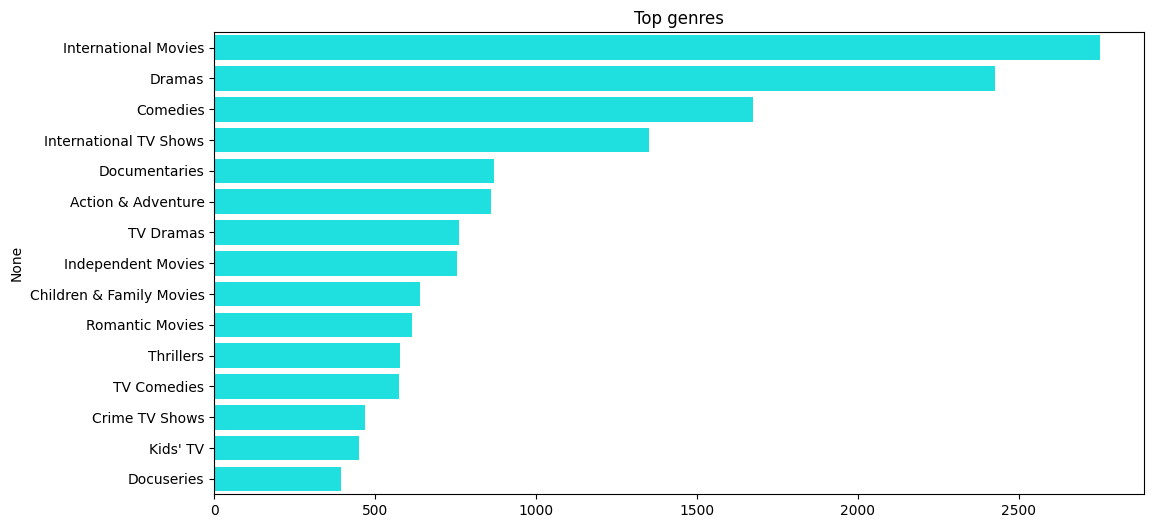

In [112]:
#top genres
genres=data['listed_in'].str.split(', ',expand=True).stack()
genres.value_counts().head(15)
top_genres=genres.value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values,y=top_genres.index,color='cyan')
plt.title("Top genres")
# plt.show()

In [50]:
# Netflix_Data_Analysis/
# │
# ├── netflix_titles.csv
# ├── Netflix_Data_Analysis.ipynb
# ├── README.md
# ├── requirements.txt
# ├── images/
# │   ├── movies_vs_tvshows.png
# │   ├── top_countries.png
# │   ├── top_genres.png
# │   ├── release_year.png
# │   └── ratings.png
# └── report.pdf

In [1]:
#The Netflix dataset shows that the platform primarily focuses on movies, with the United States contributing the largest share of content. Drama, International Movies, and Comedies dominate the catalog. Most movies have durations between 80 and 120 minutes, while one-season TV shows are the most common. The number of titles added to Netflix increased rapidly over several years, reflecting the platform's global expansion.

In [ ]:
# Bussiness questions

# 1.movies or tv shows
data['type'].value_counts()

# 2.which country produces more content
data['country'].value_counts().head(10)


# 3. which year had maximum content
# data['year_added'].value_counts().head()

# 4 most common rating
data['rating'].value_counts()

# 5 Top director
data['director'].value_counts().head(10)

# 6.Top Genre 
genres.value_counts().head(10)

# 7. Average movie duration
# movies['duration'].mean()

# 8.Longest Movie
# movies.sort_values('duration',ascending=False)[['title','duration']].head()

# 9.oldest movie
movies.sort_values('release_year')[['title','release_year']].head()

# 10.latest movies
movies.sort_values('release_year',ascending=False)[['title','release_year']].head()